# 01 — Data Exploration

Stage 5 EDA, as a thin notebook over the tested `src/analytics` modules — all logic lives in `src/`, this notebook only calls it and displays results (see `SOFTWARE_ENGINEERING.md`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
from src.analytics.market_stats import compute_market_stats, summary_stats
from src.config import RAW_DIR
%matplotlib inline

## Load ingested market data and compute descriptive statistics

In [2]:
market_dir = RAW_DIR / 'market_prices'
prices = {p.stem: pd.read_parquet(p) for p in sorted(market_dir.glob('*.parquet'))}
stats = {mid: compute_market_stats(df) for mid, df in prices.items()}
summary = pd.DataFrame({mid: summary_stats(df) for mid, df in stats.items()}).T
summary.sort_values('total_return', ascending=False)

,n_days,start_date,end_date,mean_daily_return,annualized_volatility,max_drawdown,total_return
MU,824,2023-06-01,2026-09-14,0.003913,0.616809,-0.578234,12.374296
NVDA,824,2023-06-01,2026-09-14,0.002454,0.462377,-0.368868,4.304501
SOL,1202,2023-06-01,2026-09-14,0.00226,0.679291,-0.762516,3.999218
AVGO,824,2023-06-01,2026-09-14,0.002257,0.483039,-0.41484,3.36382
TSM,824,2023-06-01,2026-09-14,0.002054,0.388986,-0.370626,3.229158
AMD,824,2023-06-01,2026-09-14,0.002362,0.564903,-0.630003,3.129991
SOXX,824,2023-06-01,2026-09-14,0.001663,0.386502,-0.416701,2.077336
BTC,1202,2023-06-01,2026-09-14,0.001183,0.383269,-0.5306,1.914372
GOOGL,824,2023-06-01,2026-09-14,0.001443,0.301658,-0.298866,1.824038
META,824,2023-06-01,2026-09-14,0.001354,0.36711,-0.342093,1.441583


## Cumulative return by asset

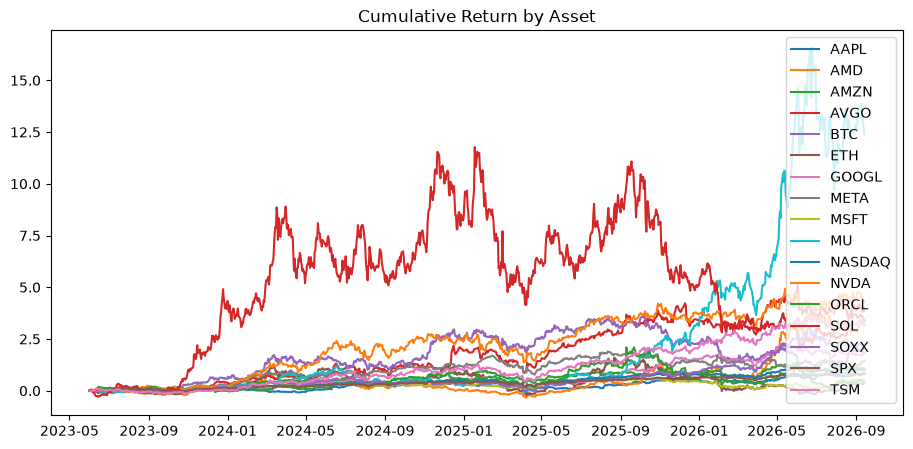

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
for mid, df in stats.items():
    ax.plot(df['date'], df['cumulative_return'], label=mid)
ax.set_title('Cumulative Return by Asset')
ax.legend()
plt.show()

## Return correlation matrix

In [4]:
returns_wide = pd.DataFrame({mid: df.set_index('date')['log_return_1d'] for mid, df in stats.items()})
returns_wide.corr().round(2)

,AAPL,AMD,AMZN,AVGO,BTC,ETH,GOOGL,META,MSFT,MU,NASDAQ,NVDA,ORCL,SOL,SOXX,SPX,TSM
AAPL,1.00,0.28,0.36,0.29,0.15,0.20,0.36,0.33,0.35,0.20,0.59,0.30,0.15,0.14,0.36,0.60,0.30
AMD,0.28,1.00,0.38,0.50,0.24,0.28,0.35,0.35,0.32,0.57,0.66,0.54,0.34,0.25,0.78,0.60,0.60
AMZN,0.36,0.38,1.00,0.38,0.22,0.25,0.56,0.57,0.53,0.31,0.70,0.44,0.31,0.24,0.45,0.66,0.42
AVGO,0.29,0.50,0.38,1.00,0.20,0.26,0.34,0.35,0.36,0.55,0.69,0.62,0.46,0.19,0.73,0.62,0.66
BTC,0.15,0.24,0.22,0.20,1.00,0.82,0.18,0.19,0.23,0.18,0.35,0.24,0.18,0.74,0.26,0.35,0.20
ETH,0.20,0.28,0.25,0.26,0.82,1.00,0.25,0.23,0.25,0.24,0.41,0.28,0.21,0.73,0.33,0.40,0.26
GOOGL,0.36,0.35,0.56,0.34,0.18,0.25,1.00,0.42,0.36,0.26,0.63,0.37,0.27,0.21,0.39,0.57,0.37
META,0.33,0.35,0.57,0.35,0.19,0.23,0.42,1.00,0.43,0.25,0.62,0.44,0.27,0.23,0.39,0.58,0.38
MSFT,0.35,0.32,0.53,0.36,0.23,0.25,0.36,0.43,1.00,0.21,0.62,0.43,0.45,0.23,0.33,0.58,0.35
MU,0.20,0.57,0.31,0.55,0.18,0.24,0.26,0.25,0.21,1.00,0.60,0.51,0.34,0.16,0.79,0.56,0.61


Full write-up with every figure: see `EDA_SUMMARY.md` in the project root.